**Installing and importing the libraries**

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score


**Loading the Dataset - 500 user cases**

In [2]:
df = pd.read_csv('/content/500_Reddit_users_posts_labels.csv')

print("Original shape:", df.shape)
print(df.head())
print(df.info())

Original shape: (500, 3)
     User                                               Post       Label
0  user-0  ['Its not a viable option, and youll be leavin...  Supportive
1  user-1  ['It can be hard to appreciate the notion that...    Ideation
2  user-2  ['Hi, so last night i was sitting on the ledge...    Behavior
3  user-3  ['I tried to kill my self once and failed badl...     Attempt
4  user-4  ['Hi NEM3030. What sorts of things do you enjo...    Ideation
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   User    500 non-null    object
 1   Post    500 non-null    object
 2   Label   500 non-null    object
dtypes: object(3)
memory usage: 11.8+ KB
None


**Cleaning the data**

In [3]:
df = df.rename(columns={
    'Post': 'text',
    'Label': 'label'
})

df = df[['text', 'label']].dropna()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text'] = df['text'].apply(clean_text)

# Removing the empty rows after cleaning
df = df[df['text'].str.len() > 0]

print("\nCleaned shape:", df.shape)
print("\nClass distribution:")
print(df['label'].value_counts())


Cleaned shape: (500, 2)

Class distribution:
label
Ideation      171
Supportive    108
Indicator      99
Behavior       77
Attempt        45
Name: count, dtype: int64


**Label encoding**

In [4]:
label_map = {
    'Supportive': 0,
    'Indicator': 1,
    'Ideation': 2,
    'Behavior': 3,
    'Attempt': 4
}

reverse_label_map = {v: k for k, v in label_map.items()}

df['label_num'] = df['label'].map(label_map)
df = df.dropna(subset=['label_num'])
df['label_num'] = df['label_num'].astype(int)


**Training the test split**

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'],
    df['label_num'],
    test_size=0.2,
    random_state=42,
    stratify=df['label_num']
)

**Training multiple models **

In [6]:
models = {
    "Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=12000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.90,
            sublinear_tf=True,
            stop_words="english"
        )),
        ("clf", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="liblinear"
        ))
    ]),

    "Linear SVM": Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=12000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.90,
            sublinear_tf=True,
            stop_words="english"
        )),
        ("clf", LinearSVC(
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Complement Naive Bayes": Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=12000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.90,
            sublinear_tf=True,
            stop_words="english"
        )),
        ("clf", ComplementNB())
    ])
}

results = []

for name, pipeline in models.items():
    print("\n===============================")
    print("Training:", name)
    print("===============================")

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision_weighted": precision,
        "Recall_weighted": recall,
        "F1_weighted": f1
    })

    print(classification_report(
        y_test,
        y_pred,
        labels=[0, 1, 2, 3, 4],
        target_names=["Supportive", "Indicator", "Ideation", "Behavior", "Attempt"],
        zero_division=0
    ))


Training: Logistic Regression
              precision    recall  f1-score   support

  Supportive       0.79      0.50      0.61        22
   Indicator       0.14      0.05      0.07        20
    Ideation       0.42      0.94      0.58        34
    Behavior       0.00      0.00      0.00        15
     Attempt       0.00      0.00      0.00         9

    accuracy                           0.44       100
   macro avg       0.27      0.30      0.25       100
weighted avg       0.34      0.44      0.35       100


Training: Linear SVM
              precision    recall  f1-score   support

  Supportive       0.60      0.55      0.57        22
   Indicator       0.19      0.15      0.17        20
    Ideation       0.40      0.62      0.48        34
    Behavior       0.10      0.07      0.08        15
     Attempt       0.00      0.00      0.00         9

    accuracy                           0.37       100
   macro avg       0.26      0.28      0.26       100
weighted avg       0.32 

**Comparing the models**

In [7]:
results_df = pd.DataFrame(results).sort_values(by="F1_weighted", ascending=False)

print("\nModel Comparison:")
print(results_df)

best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("\nBest Model:", best_model_name)


Model Comparison:
                    Model  Accuracy  Precision_weighted  Recall_weighted  \
0     Logistic Regression      0.44            0.342727             0.44   
1              Linear SVM      0.37            0.319217             0.37   
2  Complement Naive Bayes      0.34            0.116768             0.34   

   F1_weighted  
0     0.345295  
1     0.335186  
2     0.173835  

Best Model: Logistic Regression


**Finalizing the best model comparison**

In [8]:
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

print("\nFinal Classification Report for Best Model:")
print(classification_report(
    y_test,
    y_pred_best,
    labels=[0, 1, 2, 3, 4],
    target_names=["Supportive", "Indicator", "Ideation", "Behavior", "Attempt"],
    zero_division=0
))

accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred_best, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred_best, average="weighted", zero_division=0)

print("\nFinal Metrics:")
print("Accuracy:", round(accuracy, 3))
print("Precision (weighted):", round(precision, 3))
print("Recall (weighted):", round(recall, 3))
print("F1-score (weighted):", round(f1, 3))



Final Classification Report for Best Model:
              precision    recall  f1-score   support

  Supportive       0.79      0.50      0.61        22
   Indicator       0.14      0.05      0.07        20
    Ideation       0.42      0.94      0.58        34
    Behavior       0.00      0.00      0.00        15
     Attempt       0.00      0.00      0.00         9

    accuracy                           0.44       100
   macro avg       0.27      0.30      0.25       100
weighted avg       0.34      0.44      0.35       100


Final Metrics:
Accuracy: 0.44
Precision (weighted): 0.343
Recall (weighted): 0.44
F1-score (weighted): 0.345


**Displaying the confusion matrix**

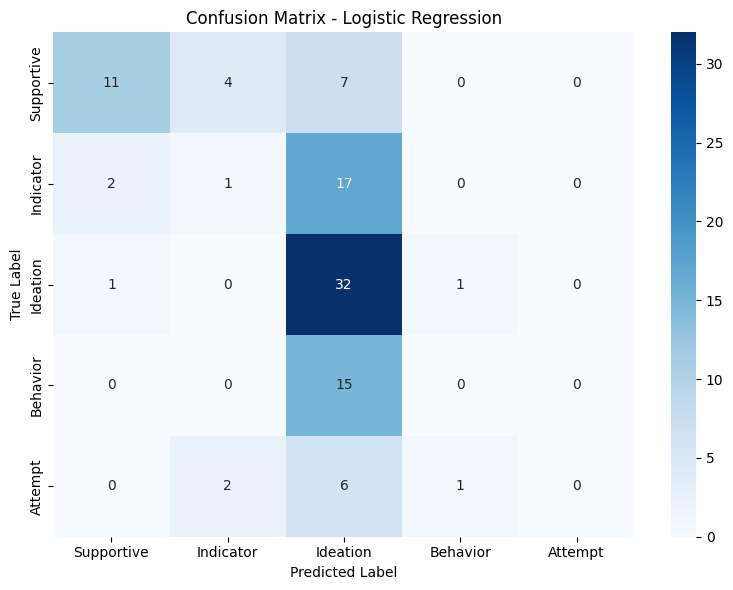

In [9]:
labels = [0, 1, 2, 3, 4]
label_names = ["Supportive", "Indicator", "Ideation", "Behavior", "Attempt"]

cm = confusion_matrix(y_test, y_pred_best, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix_reddit_improved.png", dpi=300)
plt.show()

**Displaying the class distribution**

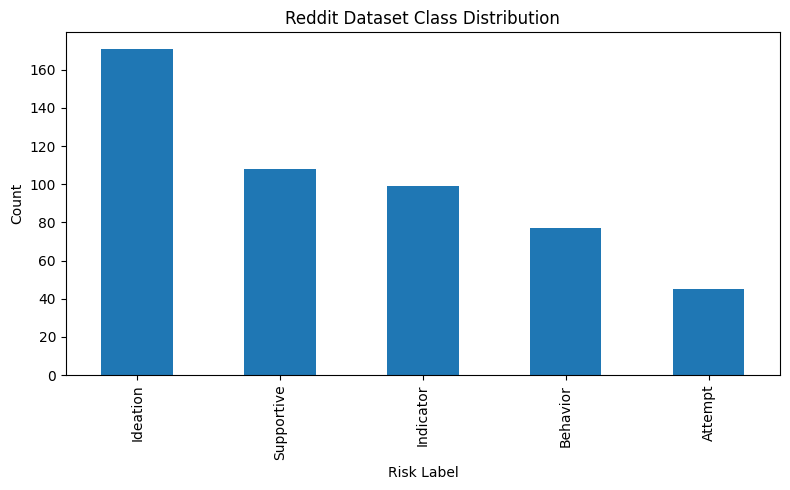

In [10]:
plt.figure(figsize=(8, 5))
df['label'].value_counts().plot(kind='bar')
plt.title("Reddit Dataset Class Distribution")
plt.xlabel("Risk Label")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("reddit_class_distribution.png", dpi=300)
plt.show()


**Test predictions**

In [11]:
example_texts = [
    "I feel like there is no point anymore and everyone would be better without me.",
    "I am planning a trip next week and feeling excited.",
    "I keep thinking about ending everything but I am scared.",
    "By next month I think I will be gone."
]

example_preds = best_model.predict(example_texts)

print("\nExample Predictions:")
for text, pred in zip(example_texts, example_preds):
    print("Text:", text)
    print("Predicted label:", reverse_label_map[pred])
    print("---")


Example Predictions:
Text: I feel like there is no point anymore and everyone would be better without me.
Predicted label: Ideation
---
Text: I am planning a trip next week and feeling excited.
Predicted label: Ideation
---
Text: I keep thinking about ending everything but I am scared.
Predicted label: Supportive
---
Text: By next month I think I will be gone.
Predicted label: Supportive
---
